# Assignment 11.1: What Drives the Price of a Car? <a id = 'top'></a>

**Each phase of the process:**
1. [Business Understanding](#business-understanding)
2. [Data Understanding](#data-understanding)
3. [Data Preparation](#data-preparation)
4. [Modeling](#modeling)
5. [Evaluation](#evaluation)
6. [Deployment](#deployment)

## 1. Business Understanding <a id = "business-understanding"></a>

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

### Business Problem
The client is a used car dealership. The assignment states the goal is to
understand what factors make a used car more or less expensive, so the
dealership can learn what consumers value in a used car.

### Business Objective
Analyze the dataset to identify which factors are associated with used car
prices, and provide clear, actionable recommendations to the dealership
about what consumers value.

### Data Science Problem
This is a regression problem: price is a continuous target variable, and the
task is to determine which features in the dataset are associated with it
and how.

### Success Criteria
- Clear identification of key drivers of used car price
- A final report translating technical findings into concrete, non-technical
  recommendations for inventory decisions

[Back to Top](#top)

## 2. Data Understanding <a id = "data-understanding"></a>

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

### Data Overview
- Source: Kaggle used car dataset (subset of ~426K rows sampled from an
  original 3M-row dataset)
- Format: single CSV file

In [3]:
import pandas as pd
import numpy as ny
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
dir = "G:\\My Drive\\Berkeley AI ML\\Module 11 - Practical Application 2\\practical_application_II_starter\\data"
data = pd.read_csv(dir + "\\vehicles.csv")

print(data.head())

           id                  region  price  year manufacturer model  \
0  7222695916                prescott   6000   NaN          NaN   NaN   
1  7218891961            fayetteville  11900   NaN          NaN   NaN   
2  7221797935            florida keys  21000   NaN          NaN   NaN   
3  7222270760  worcester / central MA   1500   NaN          NaN   NaN   
4  7210384030              greensboro   4900   NaN          NaN   NaN   

  condition cylinders fuel  odometer title_status transmission  VIN drive  \
0       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
1       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
2       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
3       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
4       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   

  size type paint_color state  
0  NaN  NaN         NaN    az  
1  NaN  NaN         NaN    ar  
2 

### Data Description

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

In [8]:
data.describe().round(2)

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.00,422480.00
mean,7.311487e+09,7.519903e+04,2011.24,98043.33
std,4.473170e+06,1.218228e+07,9.45,213881.50
min,7.207408e+09,0.000000e+00,1900.00,0.00
25%,7.308143e+09,5.900000e+03,2008.00,37704.00
50%,7.312621e+09,1.395000e+04,2013.00,85548.00
75%,7.315254e+09,2.648575e+04,2017.00,133542.50
max,7.317101e+09,3.736929e+09,2022.00,10000000.00


### Data Quality

In [ ]:
# Check for missing values
data.isna().sum()

id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

[Back to Top](#top)

## 3. Data Preparation <a id = "data-preparation"></a>

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [24]:
# Define column groups per data type
numeric_columns = data.drop(columns = ['id']).select_dtypes(include=['int', 'float']).columns # dropping id which doesn't have analytical value
numeric_features = numeric_columns.drop('price') # dropping price which is the target variable
categorical_columns = data.select_dtypes(include=['str']).columns
categorical_features = categorical_columns.drop('VIN') # dropping VIN which doesn't have analytical value

print("Numeric columns:", numeric_columns)
print("Numeric features:", numeric_features)
print("Categorical columns:", categorical_columns)
print("Categorical features:", categorical_features)

Numeric columns: Index(['price', 'year', 'odometer'], dtype='str')
Numeric features: Index(['year', 'odometer'], dtype='str')
Categorical columns: Index(['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'VIN', 'drive', 'size', 'type',
       'paint_color', 'state'],
      dtype='str')
Categorical features: Index(['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color',
       'state'],
      dtype='str')


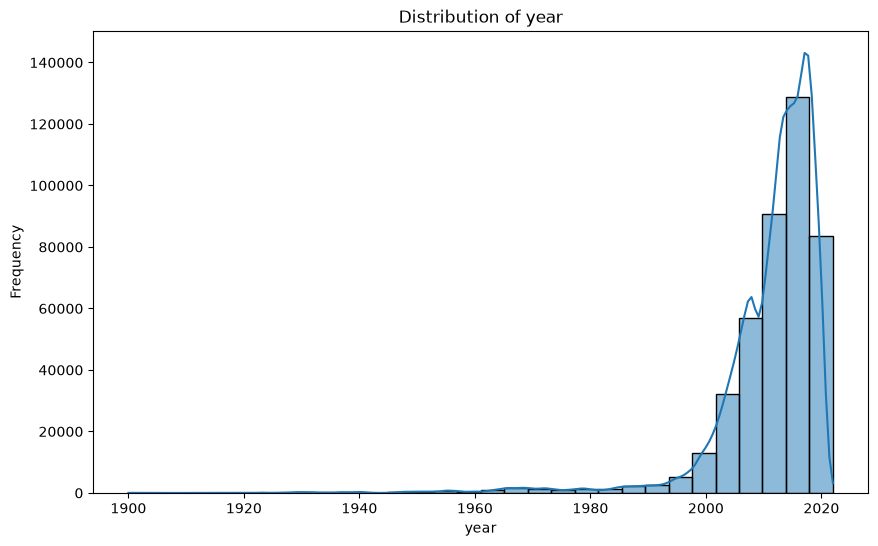

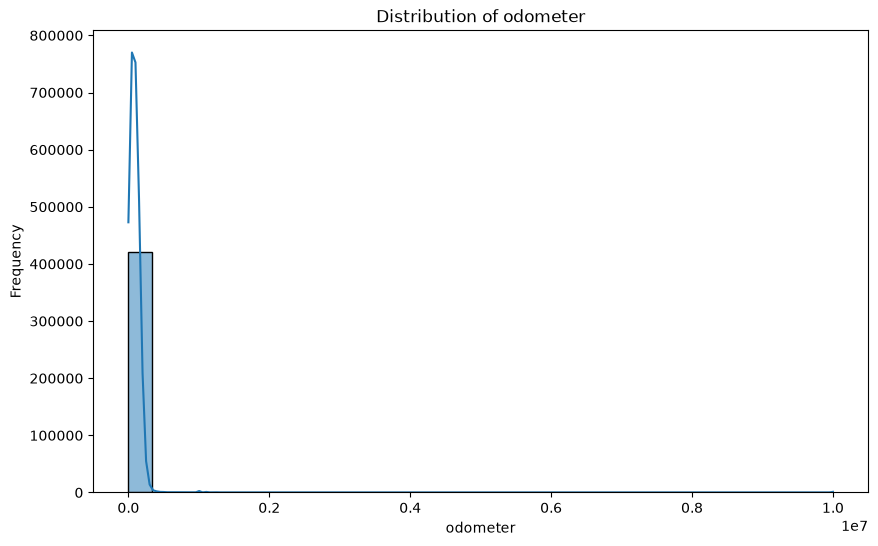

In [ ]:
# plot dristribution of numeric features
for col in numeric_features:
    plt.figure(figsize=(10, 6))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [20]:
# value counts for categorical features to check which features potentially have analytical value
for col in categorical_features:
    print("--------------------------------")
    print("--------------------------------")
    print(f"Value counts for {col}:")
    print(data[col].value_counts())

--------------------------------
--------------------------------
Value counts for region:
region
columbus                   3608
jacksonville               3562
spokane / coeur d'alene    2988
eugene                     2985
fresno / madera            2983
                           ... 
meridian                     28
southwest MS                 14
kansas city                  11
fort smith, AR                9
west virginia (old)           8
Name: count, Length: 404, dtype: int64
--------------------------------
--------------------------------
Value counts for manufacturer:
manufacturer
ford               70985
chevrolet          55064
toyota             34202
honda              21269
nissan             19067
jeep               19014
ram                18342
gmc                16785
bmw                14699
dodge              13707
mercedes-benz      11817
hyundai            10338
subaru              9495
volkswagen          9345
kia                 8457
lexus               8200
a

In [25]:
categorical_features = categorical_features.drop(['region', 'model']) # dropping features which has too many unique values to be useful
data[categorical_features].isna().sum() # check for missing values in the remaining categorical features

manufacturer     17646
condition       174104
cylinders       177678
fuel              3013
title_status      8242
transmission      2556
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

In [ ]:
vehicles = data.drop(columns = ['id', 'VIN', 'region', 'manufacturer', 'model', 'state']) # drop fields which are not useful for analysis

vehicles['cylinders_numeric'] = vehicles['cylinders'].str.extract('(\d+)').astype(float) # convert cylinders to numeric
vehicles['cylinders_numeric'] = vehicles['cylinders_numeric'].fillna(vehicles['cylinders_numeric'].median()) # fill missing values with median

vehicles['condition_numeric'] = vehicles['condition'].map({'new': 5, 'like new': 4, 'excellent': 3, 'good': 2, 'fair': 1, 'salvage': 0}) # convert condition to numeric
vehicles['condition_numeric'] = vehicles['condition_numeric'].fillna(vehicles['condition_numeric'].median()) # fill missing values with median

for col in ['fuel', 'title_status', 'transmission']:
    vehicles[col] = vehicles[col].fillna(vehicles[col].mode()[0])


# vehicles = vehicles.drop(columns = ['cylinders']) # drop original cylinders column

# vehicles.shape

(84640, 18)

[Back to Top](#top)

## 4. Modeling <a id = "modeling"></a>

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

[Back to Top](#top)

## 5. Evaluation <a id = 'evaluation'></a>

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

[Back to Top](#top)

## 6. Deployment <a id = "deployment"></a>

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.